# Butterfly & Moth Classification — 100 Species
MLOps Summative — Evaluation of Models notebook.

Covers: EDA, preprocessing, EfficientNetB0 transfer learning with optimization (frozen backbone, dropout, early stopping, LR scheduling), and 5 evaluation metrics (accuracy, loss, F1, precision, recall) plus a confusion matrix.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.applications import EfficientNetB0 # type: ignore
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = '../data'  # expects data/train, data/valid, data/test (from Kaggle download)
CSV_PATH = os.path.join(DATA_DIR, 'butterflies_and_moths.csv')

## 1. Load label index and inspect dataset

In [3]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print(df.shape)
df.head()

(13594, 4)


,class_id,filepaths,labels,data_set
0,0,train/ADONIS/001.jpg,ADONIS,train
1,0,train/ADONIS/002.jpg,ADONIS,train
2,0,train/ADONIS/003.jpg,ADONIS,train
3,0,train/ADONIS/004.jpg,ADONIS,train
4,0,train/ADONIS/005.jpg,ADONIS,train


In [4]:
print('Splits:')
print(df['data_set'].value_counts())
print('\nNumber of species:', df['labels'].nunique())

Splits:
data_set
train    12594
test       500
valid      500
Name: count, dtype: int64

Number of species: 100


## 2. EDA — class distribution

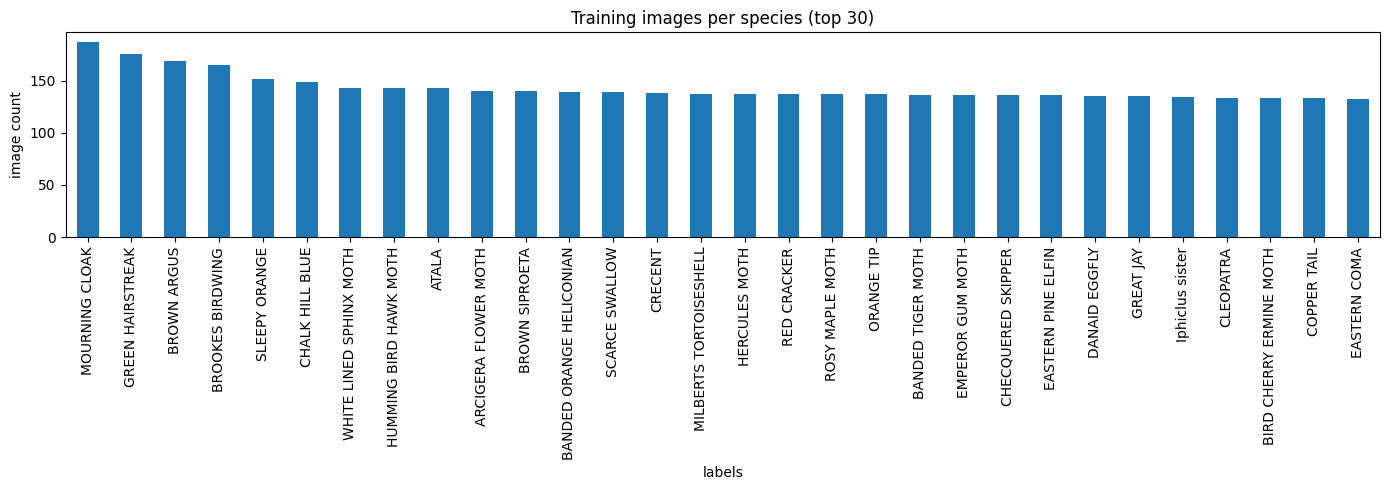

Min images in a class: 100
Max images in a class: 187
Mean images per class: 125.9


In [5]:
train_counts = df[df['data_set'] == 'train']['labels'].value_counts()

plt.figure(figsize=(14, 5))
train_counts.head(30).plot(kind='bar')
plt.title('Training images per species (top 30)')
plt.ylabel('image count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Min images in a class:', train_counts.min())
print('Max images in a class:', train_counts.max())
print('Mean images per class:', train_counts.mean().round(1))

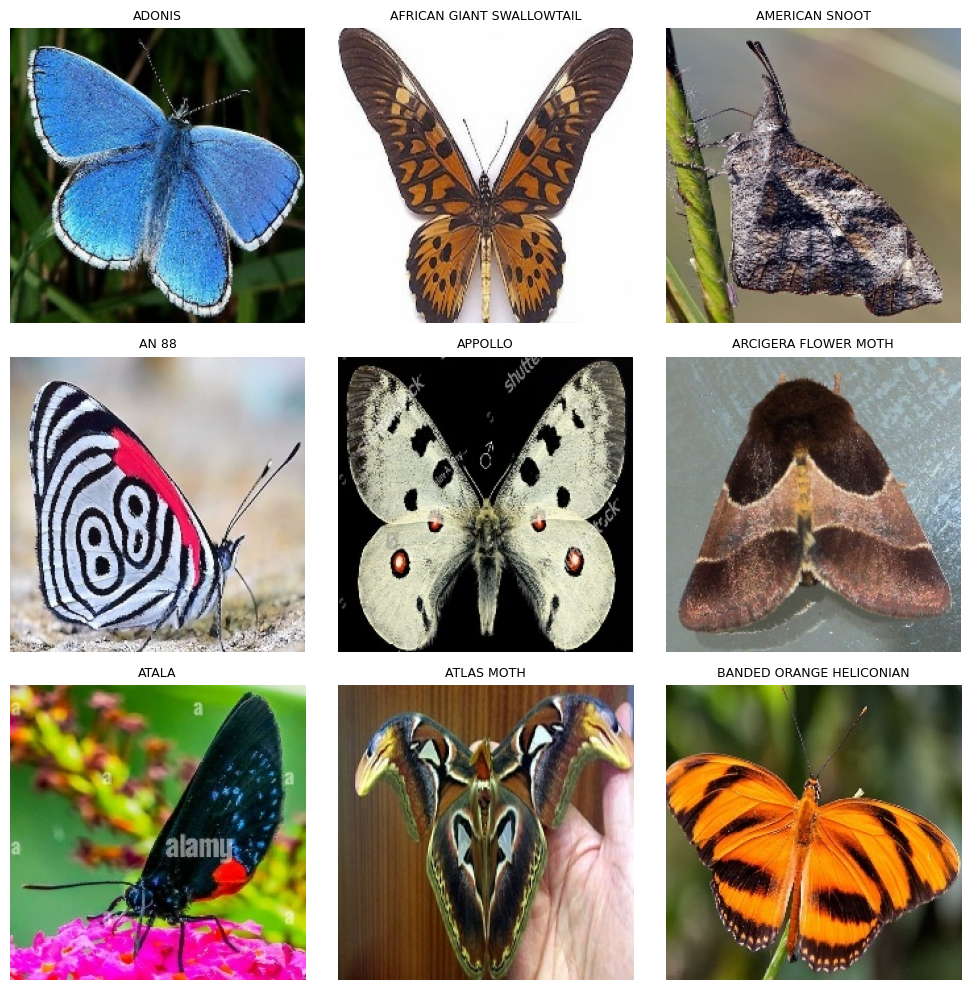

In [6]:
# Sample image grid across a handful of species
sample_species = df['labels'].unique()[:9]
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, species in zip(axes.flat, sample_species):
    row = df[(df['labels'] == species) & (df['data_set'] == 'train')].iloc[0]
    img_path = os.path.join(DATA_DIR, row['filepaths'])
    if os.path.exists(img_path):
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        ax.imshow(img)
    ax.set_title(species, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Preprocessing — build tf.data pipelines
Resize to 224x224, batch, and prefetch. Pixel values are kept in the raw [0,255]
range — EfficientNetB0 has its own built-in Rescaling/Normalization layers, so
images are NOT divided by 255 here. Class ordering is taken from `image_dataset_from_directory`
and must match `src/preprocessing.get_class_list()` used at serve time.

In [7]:
classes = sorted(df['labels'].unique().tolist())
num_classes = len(classes)
print('Num classes:', num_classes)

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', class_names=classes, seed=42
)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'valid'), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', class_names=classes, seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'), image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical', class_names=classes, shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

# NOTE: no Rescaling(1/255) here. EfficientNetB0 already has its own built-in
# Rescaling + Normalization layers (verified: backbone.layers[1:3] are named
# 'rescaling'/'normalization') and expects raw [0,255] pixel values. Dividing
# by 255 here as well double-scales the input and prevents the model from
# learning (this caused a real bug: training was stuck at random-guess loss).
CACHE_DIR = os.path.join(DATA_DIR, '.cache')
os.makedirs(CACHE_DIR, exist_ok=True)

train_ds = train_ds.cache(os.path.join(CACHE_DIR, 'train'))
valid_ds = valid_ds.cache(os.path.join(CACHE_DIR, 'valid')).prefetch(AUTOTUNE)
test_ds_eval = test_ds.cache(os.path.join(CACHE_DIR, 'test')).prefetch(AUTOTUNE)

Num classes: 100
Found 12594 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Found 500 files belonging to 100 classes.


In [8]:
# Light augmentation applied only to the training set (helps generalization,
# counts toward 'optimization techniques' in the rubric). Applied after the
# cache, so each epoch still gets freshly randomized flips/rotations/zooms.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
train_ds = (train_ds
            .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

## 4. Model — EfficientNetB0 frozen backbone + classification head

In [9]:
def build_model(num_classes):
    backbone = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=(*IMG_SIZE, 3), pooling='avg')
    backbone.trainable = False  # frozen: fast training, avoids overfitting on limited data per class

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model(num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,403,207 (16.80 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 5. Train — with early stopping and LR reduction on plateau

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks,
)

Epoch 1/20


c:\Users\Mathieu Rwiyereka\OneDrive\Desktop\NewProject\Summative_ML_Pipelin_butterfly-mlops\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


394/394 ━━━━━━━━━━━━━━━━━━━━ 180s 435ms/step - accuracy: 0.6026 - loss: 1.6813 - val_accuracy: 0.8600 - val_loss: 0.5733 - learning_rate: 0.0010
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 169s 428ms/step - accuracy: 0.8351 - loss: 0.6090 - val_accuracy: 0.9020 - val_loss: 0.3695 - learning_rate: 0.0010
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 163s 414ms/step - accuracy: 0.8666 - loss: 0.4681 - val_accuracy: 0.9060 - val_loss: 0.3194 - learning_rate: 0.0010
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 167s 422ms/step - accuracy: 0.8845 - loss: 0.3963 - val_accuracy: 0.9220 - val_loss: 0.2866 - learning_rate: 0.0010
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 163s 413ms/step - accuracy: 0.8953 - loss: 0.3467 - val_accuracy: 0.9180 - val_loss: 0.2614 - learning_rate: 0.0010
Epoch 6/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 163s 413ms/step - accuracy: 0.9057 - loss: 0.3157 - val_accuracy: 0.9280 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 7/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 163s 414ms/step - accuracy: 0.9055 

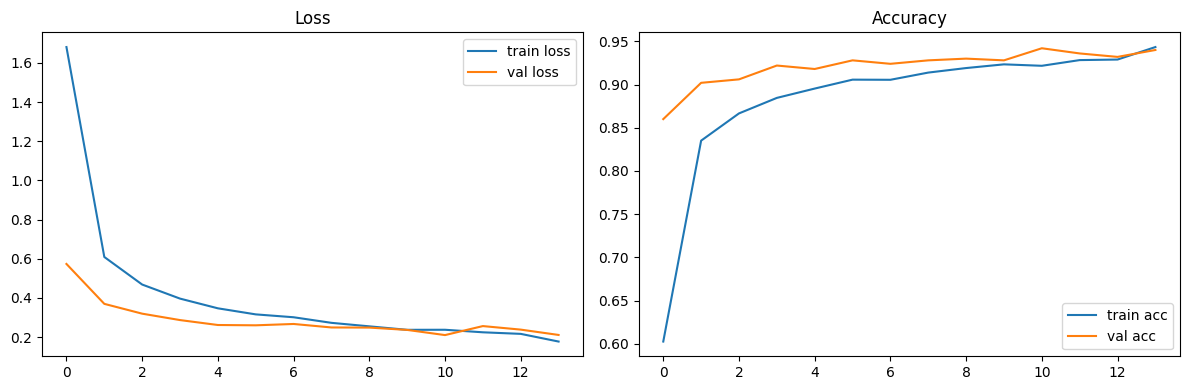

In [11]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train acc')
axes[1].plot(history.history['val_accuracy'], label='val acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Evaluate on the held-out test set — 5 metrics + confusion matrix

In [12]:
test_loss, test_accuracy = model.evaluate(test_ds_eval)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 386ms/step - accuracy: 0.9420 - loss: 0.1774
Test loss: 0.1774
Test accuracy: 0.9420


In [13]:
# Gather predictions and true labels for F1 / precision / recall / confusion matrix
# One predict() call over the whole dataset instead of one per batch — avoids
# per-call retracing overhead from calling model.predict() in a Python loop.
preds = model.predict(test_ds_eval, verbose=0)
y_pred = np.argmax(preds, axis=1)
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds_eval])

f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'Accuracy:  {test_accuracy:.4f}')
print(f'Loss:      {test_loss:.4f}')
print(f'F1 score:  {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')

Accuracy:  0.9420
Loss:      0.1774
F1 score:  0.9398
Precision: 0.9481
Recall:    0.9420


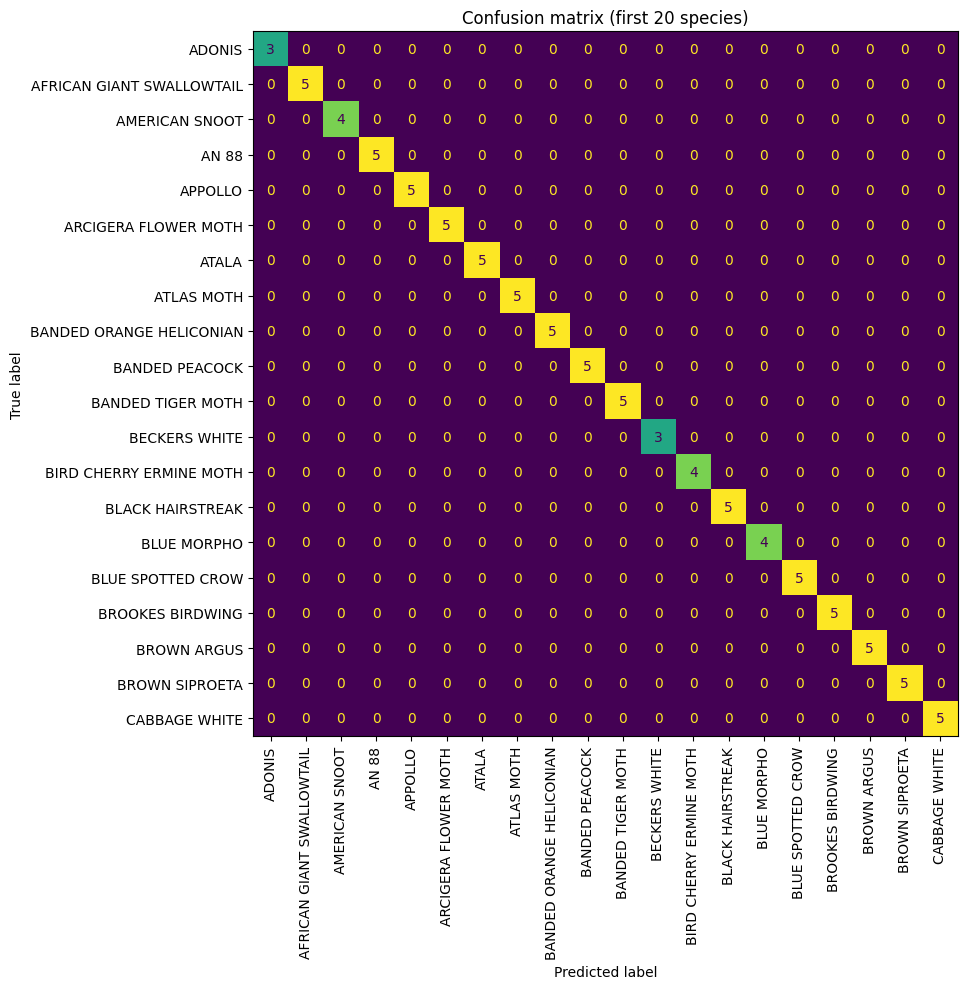

In [14]:
# Confusion matrix (subset of classes for readability)
subset = list(range(20))
mask = np.isin(y_true, subset)
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=subset)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[classes[i] for i in subset])
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title('Confusion matrix (first 20 species)')
plt.tight_layout()
plt.show()

## 7. Save the model
Saved to `models/model.keras` — this is the file `src/model.py` loads for prediction and uses as the warm-start base for the `/retrain` endpoint.

In [15]:
import shutil
os.makedirs('../models', exist_ok=True)
model.save('../models/model.keras')
print('Saved to ../models/model.keras')

Saved to ../models/model.keras
